**Project:** 6009CMD | Ariticial Nueral Networks  
**Student:** Muhammad Shayan | 14678222 

# Part A - Human-Guided for Artificial Neural Network Model

Using a dataset i found from OPENML, titled social_bias_frames, https://www.openml.org/search?type=data&status=active&qualities.NumberOfFeatures=between_10_100&qualities.NumberOfInstances=between_10000_100000&id=46823&sort=runs

In [1]:
# install all the libraries we need
%pip install tensorflow-cpu
%pip install scikit-learn
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install liac-arff
%pip install tf_keras


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# load everything we'll use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# ml and preprocessing stuff
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Conv1D, GlobalMaxPooling1D,
                                      Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping


# show plots inline in the notebook
%matplotlib inline
plt.style.use('seaborn-v0_8')

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
import arff

# paths to the dataset files
FILE_PATH = "dataset_"
CSV_PATH  = "dataset.csv"

# load the arff file and convert to dataframe
with open(FILE_PATH, 'r', encoding='utf-8') as f:
    dataset = arff.load(f)

df = pd.DataFrame(dataset['data'], columns=[attr[0] for attr in dataset['attributes']])

# arff uses '?' for missing values, swap to NaN
df.replace('?', np.nan, inplace=True)

# save a csv copy for convenience
df.to_csv(CSV_PATH, index=False)
print(f"Saved to {CSV_PATH}")
print("Shape:", df.shape)
df.head()


Saved to dataset.csv
Shape: (144649, 19)


,whoTarget,intentYN,sexYN,sexReason,offensiveYN,annotatorGender,annotatorMinority,sexPhrase,speakerMinorityYN,WorkerId,HITId,annotatorPolitics,annotatorRace,annotatorAge,post,targetMinority,targetCategory,targetStereotype,dataSource
0,0.0,0.66,0.0,NaN,1.0,woman,NaN,NaN,NaN,-8935932304856669427,363A7XIFV4G2799C5V96YERJA9AVAM,liberal,white,45.0,RT @_LexC__: I'm convinced that some of y'all ...,NaN,NaN,NaN,t/davidson
1,0.0,0.66,0.0,NaN,0.5,man,NaN,NaN,NaN,6347880360297734464,363A7XIFV4G2799C5V96YERJA9AVAM,mod-liberal,white,35.0,RT @_LexC__: I'm convinced that some of y'all ...,NaN,NaN,NaN,t/davidson
2,0.0,0.33,0.0,NaN,0.5,man,NaN,NaN,NaN,-7452610791699819066,363A7XIFV4G2799C5V96YERJA9AVAM,liberal,asian,23.0,RT @_LexC__: I'm convinced that some of y'all ...,NaN,NaN,NaN,t/davidson
3,1.0,1.0,0.0,NaN,1.0,man,NaN,NaN,0.0,-500114755446676507,3JTPR5MTZS6RLS3JBV4IOU0G2X35K5,liberal,white,25.0,RT @iBeZo: Stupid fucking nigger LeBron. You f...,black folks,race,all stupid,t/davidson
4,1.0,1.0,0.0,NaN,1.0,man,NaN,NaN,0.0,-500114755446676507,3JTPR5MTZS6RLS3JBV4IOU0G2X35K5,liberal,white,25.0,RT @iBeZo: Stupid fucking nigger LeBron. You f...,black folks,race,are not people but apes.,t/davidson


In [4]:
# quick look at the dataset
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (144649, 19)

Columns:
 ['whoTarget', 'intentYN', 'sexYN', 'sexReason', 'offensiveYN', 'annotatorGender', 'annotatorMinority', 'sexPhrase', 'speakerMinorityYN', 'WorkerId', 'HITId', 'annotatorPolitics', 'annotatorRace', 'annotatorAge', 'post', 'targetMinority', 'targetCategory', 'targetStereotype', 'dataSource']

Dtypes:
 whoTarget            str
intentYN             str
sexYN                str
sexReason            str
offensiveYN          str
annotatorGender      str
annotatorMinority    str
sexPhrase            str
speakerMinorityYN    str
WorkerId             str
HITId                str
annotatorPolitics    str
annotatorRace        str
annotatorAge         str
post                 str
targetMinority       str
targetCategory       str
targetStereotype     str
dataSource           str
dtype: object

Missing values:
 whoTarget             55843
intentYN                  0
sexYN                     0
sexReason            131354
offensiveYN               0
annotatorGender       

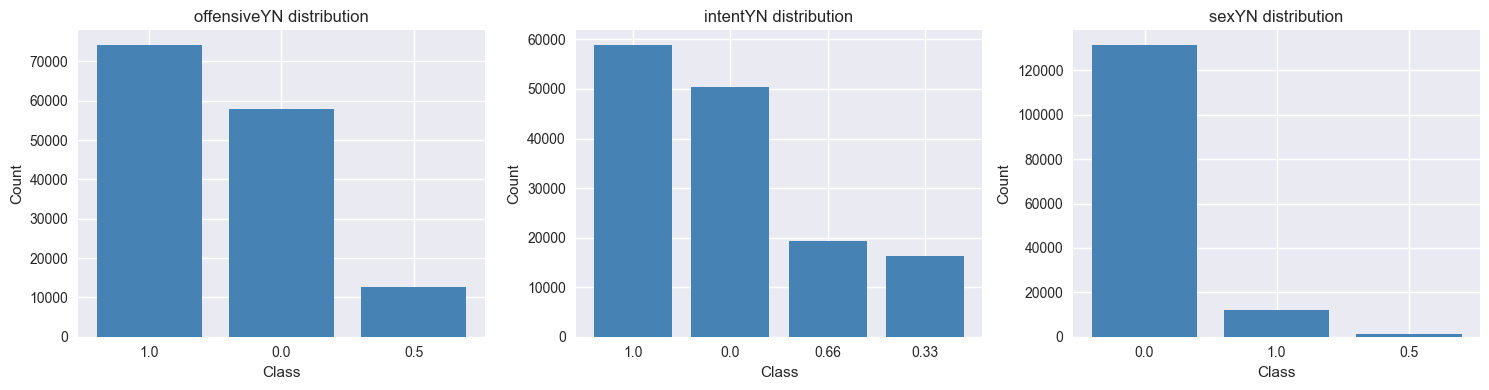

In [5]:
# plot how the three target labels are distributed
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['offensiveYN', 'intentYN', 'sexYN']):
    counts = df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color='steelblue')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

 Text Length Analysis

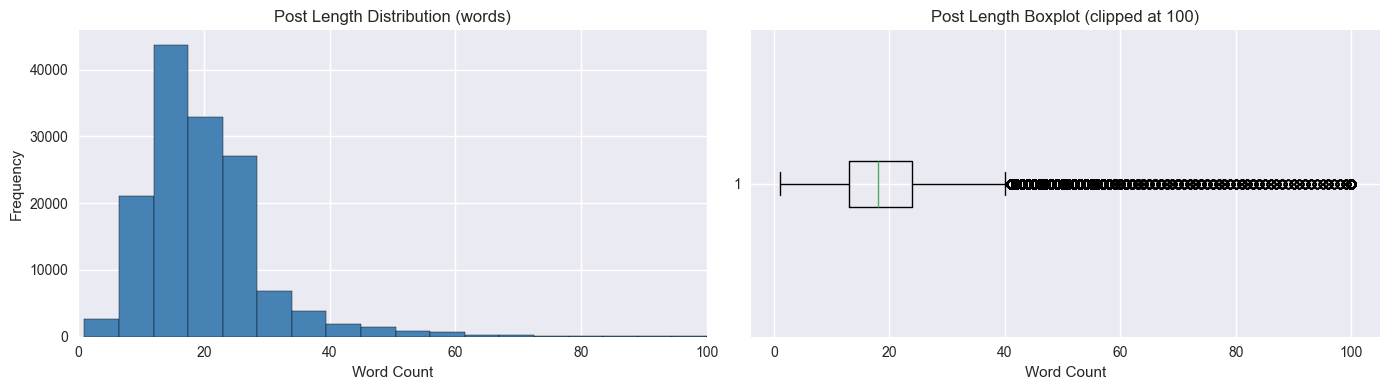

count    144649.000000
mean         20.096827
std          11.815427
min           1.000000
25%          13.000000
50%          18.000000
75%          24.000000
max         276.000000
Name: post_length, dtype: float64


In [6]:
# count words per post
df['post_length'] = df['post'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['post_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Post Length Distribution (words)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 100)

axes[1].boxplot(df['post_length'].clip(upper=100), vert=False)
axes[1].set_title('Post Length Boxplot (clipped at 100)')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

print(df['post_length'].describe())

Label Correlation Heatmap

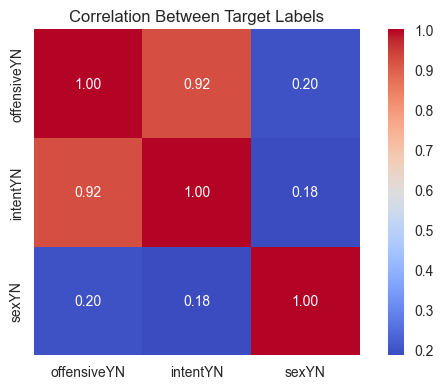

In [7]:
# see how the three labels correlate with each other
label_cols = ['offensiveYN', 'intentYN', 'sexYN']

label_numeric = df[label_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(6, 4))
sns.heatmap(label_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Between Target Labels')
plt.tight_layout()
plt.show()

Data Source Distribution

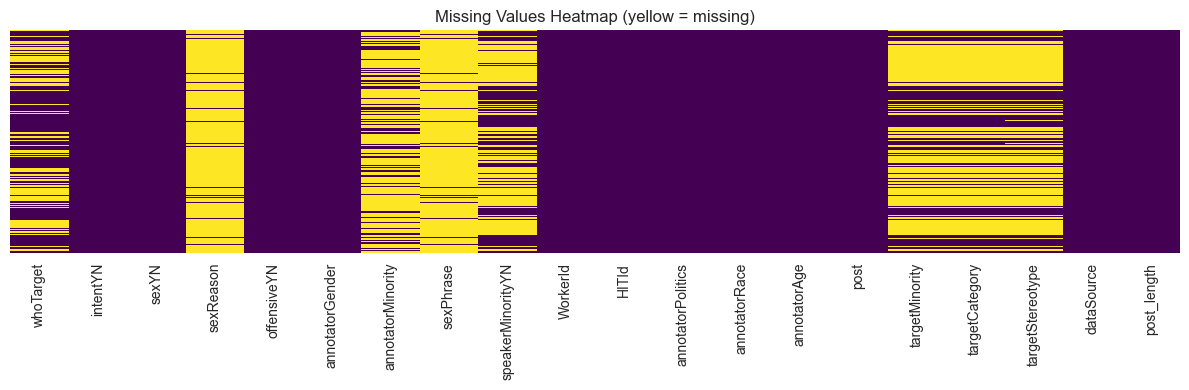

                   Missing Count  Missing %
sexReason                 131354      90.81
sexPhrase                 131342      90.80
annotatorMinority         107712      74.46
targetStereotype           85918      59.40
targetMinority             84792      58.62
targetCategory             84792      58.62
speakerMinorityYN          81181      56.12
whoTarget                  55843      38.61
annotatorGender                1       0.00
annotatorPolitics              1       0.00
annotatorRace                  1       0.00
annotatorAge                   1       0.00


In [8]:
# visualise where the missing values are
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

Top Tokens Per Offensive Class

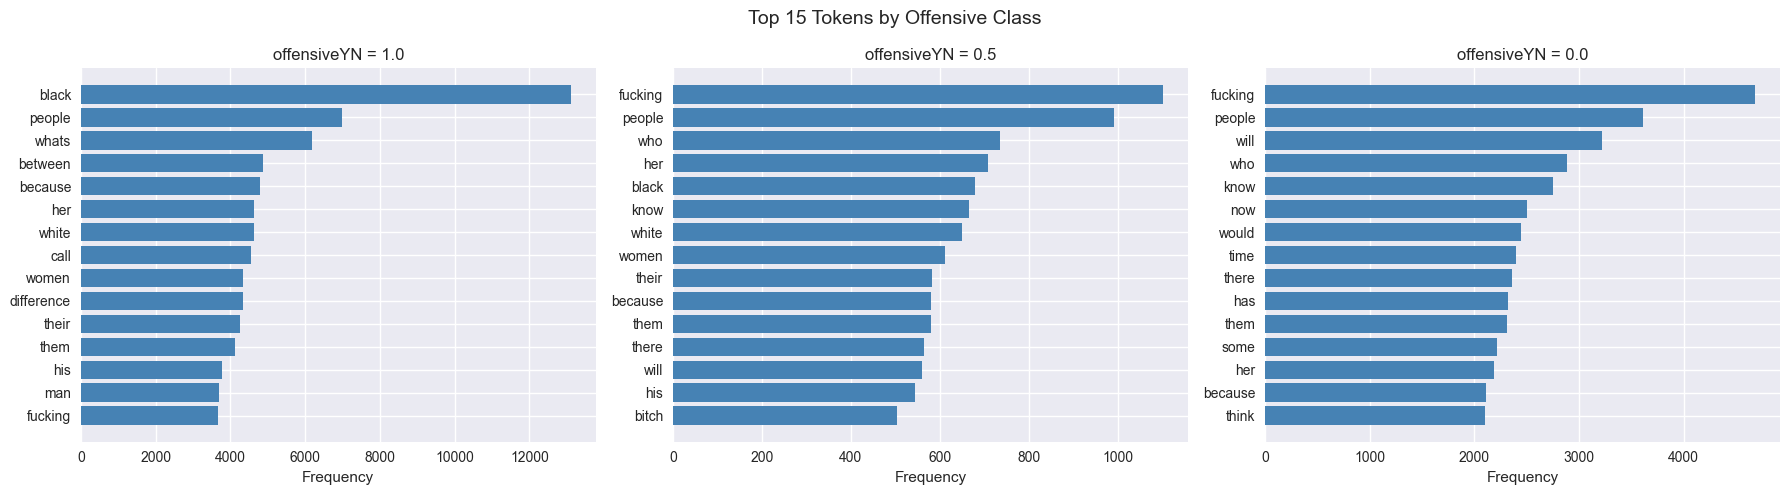

In [9]:
from collections import Counter

# basic text cleaner for the EDA
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

# common words to ignore
stopwords = set(['the','a','an','is','it','in','on','and','or','to','of',
                 'i','you','he','she','they','we','this','that','for',
                 'with','at','by','from','be','was','are','as','have',
                 'what','but','not','just','all','your','when','get',
                 'dont','how','why','like','out','its','about','up',
                 'so','do','me','my','if','no','more','one','can','been'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot top 15 words for each offensiveness class
for ax, cls in zip(axes, ['1.0', '0.5', '0.0']):
    subset = df[df['offensiveYN'] == cls]['post'].dropna()
    words = []
    for post in subset:
        tokens = clean_text(post).split()
        words.extend([w for w in tokens if w not in stopwords and len(w) > 2])
    
    top_words = Counter(words).most_common(15)
    words_list, counts = zip(*top_words)
    
    ax.barh(words_list[::-1], counts[::-1], color='steelblue')
    ax.set_title(f'offensiveYN = {cls}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Tokens by Offensive Class', fontsize=14)
plt.tight_layout()
plt.show()

 Post Length vs Offensiveness

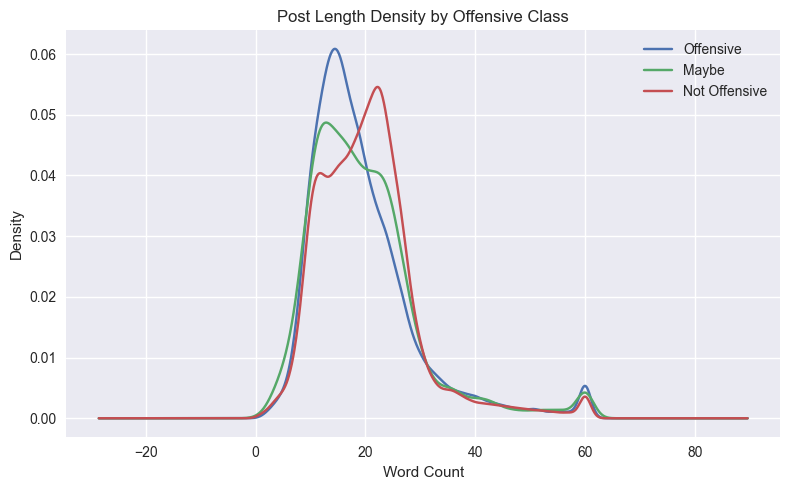

In [10]:
# compare post lengths across offensive classes
plt.figure(figsize=(8, 5))
label_map = {'1.0': 'Offensive', '0.5': 'Maybe', '0.0': 'Not Offensive'}

for cls, label in label_map.items():
    subset = df[df['offensiveYN'] == cls]['post_length'].clip(upper=60)
    subset.plot(kind='density', label=label)

plt.title('Post Length Density by Offensive Class')
plt.xlabel('Word Count')
plt.legend()
plt.tight_layout()
plt.show()

Annotator Demographics

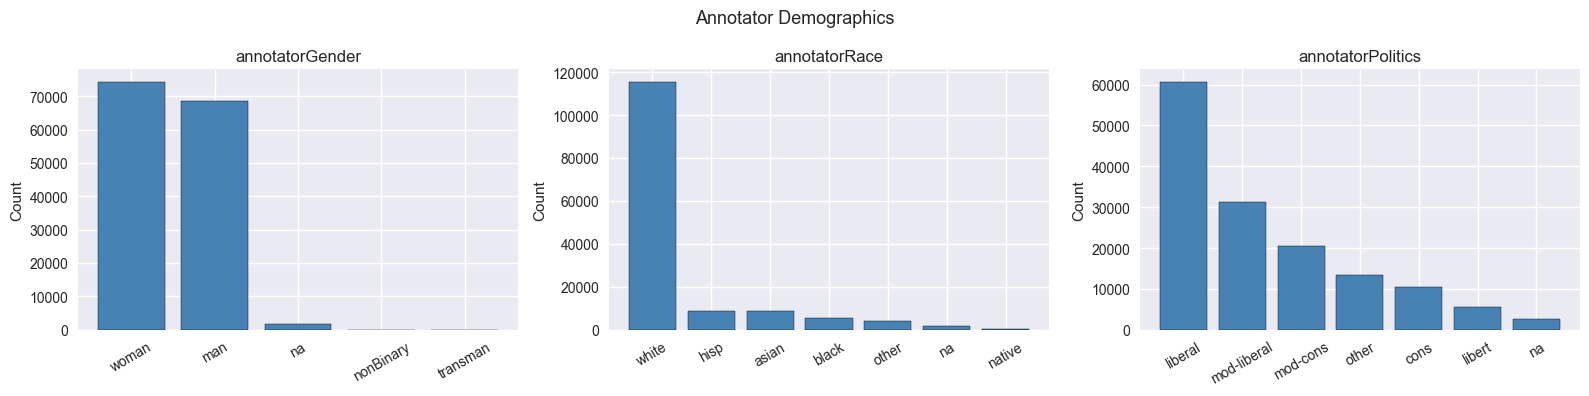

In [11]:
# look at who the annotators are
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['annotatorGender', 'annotatorRace', 'annotatorPolitics']):
    counts = df[col].value_counts().head(8)
    ax.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='black')
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Annotator Demographics', fontsize=13)
plt.tight_layout()
plt.show()

Data Source Distribution

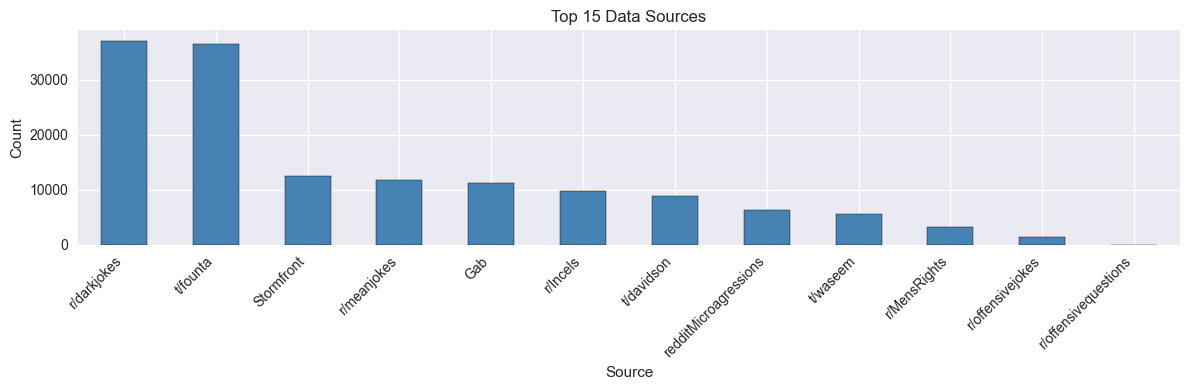

In [12]:
# see where the data came from
source_counts = df['dataSource'].value_counts().head(15)

plt.figure(figsize=(12, 4))
source_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Data Sources')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 Text Cleaning & Tokenization

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# set max sequence length and vocab size
MAX_LEN = 50
VOCAB_SIZE = 20000

# clean the text - lowercase, remove urls and special chars
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_post'] = df['post'].apply(clean_text)

# tokenise and pad to fixed length
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_post'])
sequences = tokenizer.texts_to_sequences(df['clean_post'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("X shape:", X.shape)
print("Vocabulary size:", len(tokenizer.word_index))

X shape: (144649, 50)
Vocabulary size: 46975


 Label Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder

# map the string labels to numbers
offensive_map = {'0.0': 0, '0.5': 1, '1.0': 2}
intent_map    = {'0.0': 0, '0.33': 1, '0.66': 2, '1.0': 3}
sex_map       = {'0.0': 0, '0.5': 1, '1.0': 2}

y_offensive = df['offensiveYN'].map(offensive_map).values
y_intent    = df['intentYN'].map(intent_map).values
y_sex       = df['sexYN'].map(sex_map).values

print("offensiveYN classes:", np.unique(y_offensive))
print("intentYN classes:", np.unique(y_intent))
print("sexYN classes:", np.unique(y_sex))
print("Any NaN in labels?", np.isnan(y_offensive.astype(float)).any(),
                             np.isnan(y_intent.astype(float)).any(),
                             np.isnan(y_sex.astype(float)).any())

offensiveYN classes: [0 1 2]
intentYN classes: [0 1 2 3]
sexYN classes: [0 1 2]
Any NaN in labels? False False False


Train/Val/Test Split

In [15]:
from sklearn.model_selection import train_test_split

# 15% test set
X_temp, X_test, y_off_temp, y_off_test, y_int_temp, y_int_test, y_sex_temp, y_sex_test = \
    train_test_split(X, y_offensive, y_intent, y_sex,
                     test_size=0.15, random_state=42, stratify=y_offensive)

# split the rest into ~70% train and ~15% val
X_train, X_val, y_off_train, y_off_val, y_int_train, y_int_val, y_sex_train, y_sex_val = \
    train_test_split(X_temp, y_off_temp, y_int_temp, y_sex_temp,
                     test_size=0.176, random_state=42, stratify=y_off_temp)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (101311, 50)
Val:   (21640, 50)
Test:  (21698, 50)


Class Weights

In [16]:
from sklearn.utils.class_weight import compute_class_weight

# compute balanced class weights to handle imbalance
def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return {int(k): float(v) for k, v in zip(classes, weights)}

cw_offensive = get_class_weights(y_off_train)
cw_intent    = get_class_weights(y_int_train)
cw_sex       = get_class_weights(y_sex_train)

print("offensiveYN weights:", cw_offensive)
print("intentYN weights:   ", cw_intent)
print("sexYN weights:      ", cw_sex)

offensiveYN weights: {0: 0.8326224348069068, 1: 3.8484710351377016, 2: 0.6497168619453476}
intentYN weights:    {0: 0.7178050162958765, 1: 2.238224637681159, 2: 1.8836642867767366, 3: 0.613797741372625}
sexYN weights:       {0: 0.36672204907677886, 1: 48.59040767386091, 2: 3.959471606675265}


Build Multi-Output CNN Model

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# model hyperparams
EMBED_DIM = 128

# build the CNN model
inputs = Input(shape=(MAX_LEN,), name='input')
x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN, name='embedding')(inputs)
x = Conv1D(filters=128, kernel_size=5, activation='relu', name='conv1')(x)
x = GlobalMaxPooling1D(name='pooling')(x)
x = Dense(64, activation='relu', name='dense_shared')(x)
x = Dropout(0.3, name='dropout')(x)

# three separate output heads, one per task
out_offensive = Dense(3, activation='softmax', name='offensiveYN')(x)
out_intent    = Dense(4, activation='softmax', name='intentYN')(x)
out_sex       = Dense(3, activation='softmax', name='sexYN')(x)

model = Model(inputs=inputs, outputs=[out_offensive, out_intent, out_sex])

model.compile(
    optimizer='adam',
    loss={
        'offensiveYN': 'sparse_categorical_crossentropy',
        'intentYN':    'sparse_categorical_crossentropy',
        'sexYN':       'sparse_categorical_crossentropy'
    },
    loss_weights={
        'offensiveYN': 1.0,
        'intentYN':    1.0,
        'sexYN':       2.0   # upweight sexYN due to extreme imbalance
    },
    metrics={
        'offensiveYN': 'accuracy',
        'intentYN':    'accuracy',
        'sexYN':       'accuracy'
    }
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 50)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  2,560,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 46, 128)   │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling             │ (None, 128)       │          0 │ conv1[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared        │ (None, 64)        │      8,256 │ pooling[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_shared[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ offensiveYN (Dense) │ (None, 3)         │        195 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ intentYN (Dense)    │ (None, 4)         │        260 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sexYN (Dense)       │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,650,954 (10.11 MB)

 Trainable params: 2,650,954 (10.11 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# compile with separate losses for each head
model.compile(
    optimizer='adam',
    loss={
        'offensiveYN': 'sparse_categorical_crossentropy',
        'intentYN':    'sparse_categorical_crossentropy',
        'sexYN':       'sparse_categorical_crossentropy'
    },
    loss_weights={
        'offensiveYN': 1.0,
        'intentYN':    1.0,
        'sexYN':       2.0   
    },
    metrics={
        'offensiveYN': 'accuracy',
        'intentYN':    'accuracy',
        'sexYN':       'accuracy'
    }
)

# stop early if val loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# train the model
history = model.fit(
    X_train,
    {
        'offensiveYN': y_off_train,
        'intentYN':    y_int_train,
        'sexYN':       y_sex_train
    },
    validation_data=(
        X_val,
        {
            'offensiveYN': y_off_val,
            'intentYN':    y_int_val,
            'sexYN':       y_sex_val
        }
    ),
    epochs=10,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - intentYN_accuracy: 0.6014 - intentYN_loss: 1.0409 - loss: 2.2645 - offensiveYN_accuracy: 0.7100 - offensiveYN_loss: 0.7114 - sexYN_accuracy: 0.9244 - sexYN_loss: 0.2561 - val_intentYN_accuracy: 0.6583 - val_intentYN_loss: 0.9183 - val_loss: 1.8502 - val_offensiveYN_accuracy: 0.7769 - val_offensiveYN_loss: 0.5941 - val_sexYN_accuracy: 0.9405 - val_sexYN_loss: 0.1688
Epoch 2/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - intentYN_accuracy: 0.6812 - intentYN_loss: 0.8670 - loss: 1.7183 - offensiveYN_accuracy: 0.8023 - offensiveYN_loss: 0.5450 - sexYN_accuracy: 0.9466 - sexYN_loss: 0.1532 - val_intentYN_accuracy: 0.6695 - val_intentYN_loss: 0.8825 - val_loss: 1.7446 - val_offensiveYN_accuracy: 0.7925 - val_offensiveYN_loss: 0.5598 - val_sexYN_accuracy: 0.9481 - val_sexYN_loss: 0.1509
Epoch 3/10
396/396 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - intentYN_accuracy: 0.7006 - intentYN_loss: 0.7846 - loss: 1.5012 - offensiveYN_accuracy: 0.8264 

Predictions on Test Set

In [19]:
# get predictions on the test set
y_pred = model.predict(X_test, verbose=0)

# pick the class with highest probability
y_off_pred  = np.argmax(y_pred[0], axis=1)
y_int_pred  = np.argmax(y_pred[1], axis=1)
y_sex_pred  = np.argmax(y_pred[2], axis=1)

# keep the raw probabilities for uncertainty analysis later
proba_off = y_pred[0]
proba_int = y_pred[1]
proba_sex = y_pred[2]

Classification Reports

In [20]:
# readable names for each class
label_names = {
    'offensiveYN': ['Not Offensive', 'Maybe', 'Offensive'],
    'intentYN':    ['No Intent', 'Probably Not', 'Probably Yes', 'Yes Intent'],
    'sexYN':       ['Not Sexual', 'Maybe', 'Sexual']
}

# print report for each output
for name, y_true, y_pred_cls in zip(
    ['offensiveYN', 'intentYN', 'sexYN'],
    [y_off_test, y_int_test, y_sex_test],
    [y_off_pred, y_int_pred, y_sex_pred]
):

    print(f"Classification Report: {name}")

    print(classification_report(y_true, y_pred_cls,
                                 target_names=label_names[name],
                                 zero_division=0))

Classification Report: offensiveYN
               precision    recall  f1-score   support

Not Offensive       0.80      0.83      0.81      8687
        Maybe       0.00      0.00      0.00      1879
    Offensive       0.80      0.91      0.85     11132

     accuracy                           0.80     21698
    macro avg       0.53      0.58      0.55     21698
 weighted avg       0.73      0.80      0.76     21698

Classification Report: intentYN
              precision    recall  f1-score   support

   No Intent       0.70      0.86      0.77      7523
Probably Not       0.18      0.00      0.00      2437
Probably Yes       0.29      0.01      0.02      2865
  Yes Intent       0.66      0.92      0.77      8873

    accuracy                           0.68     21698
   macro avg       0.46      0.45      0.39     21698
weighted avg       0.57      0.68      0.59     21698

Classification Report: sexYN
              precision    recall  f1-score   support

  Not Sexual       0.97   

Confusion Matrices

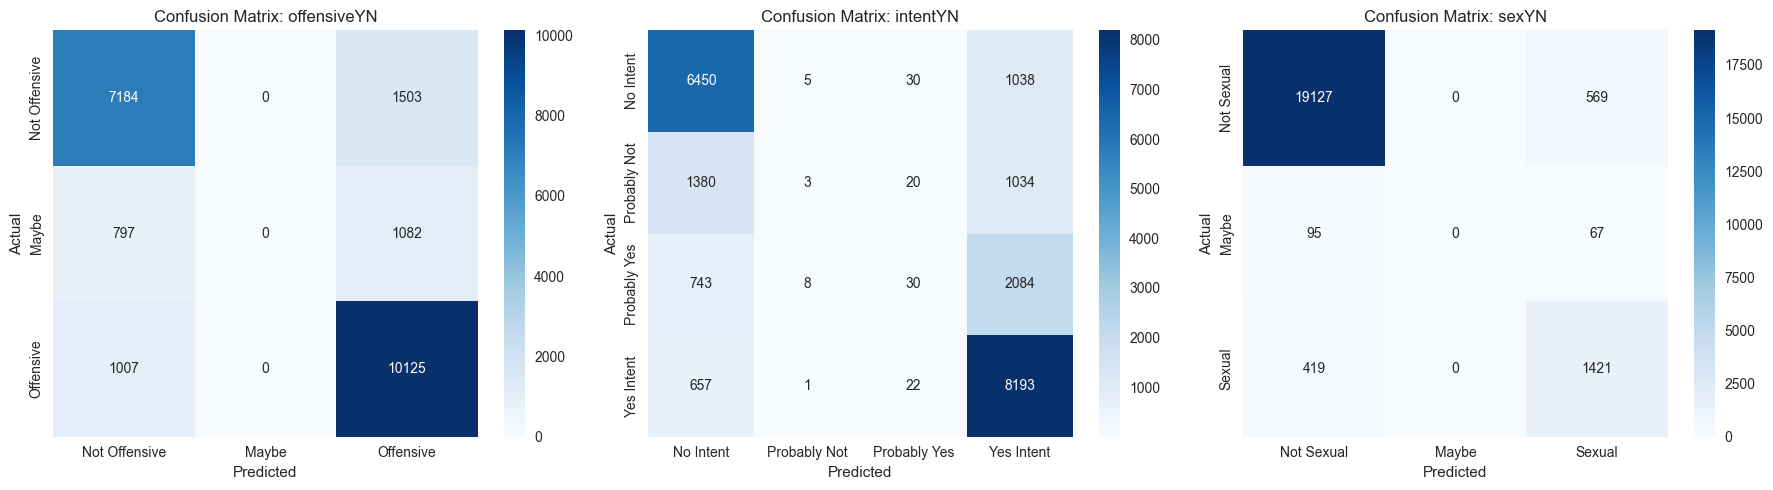

In [21]:
# plot confusion matrix for each output head
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, y_true, y_pred_cls in zip(
    axes,
    ['offensiveYN', 'intentYN', 'sexYN'],
    [y_off_test, y_int_test, y_sex_test],
    [y_off_pred, y_int_pred, y_sex_pred]
):
    cm = confusion_matrix(y_true, y_pred_cls)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names[name],
                yticklabels=label_names[name])
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

Uncertainty Analysis

Uncertain predictions (confidence < 0.6):
  offensiveYN: 3294 / 21698 (15.2%)
  intentYN:    6438 / 21698 (29.7%)
  sexYN:       645 / 21698 (3.0%)


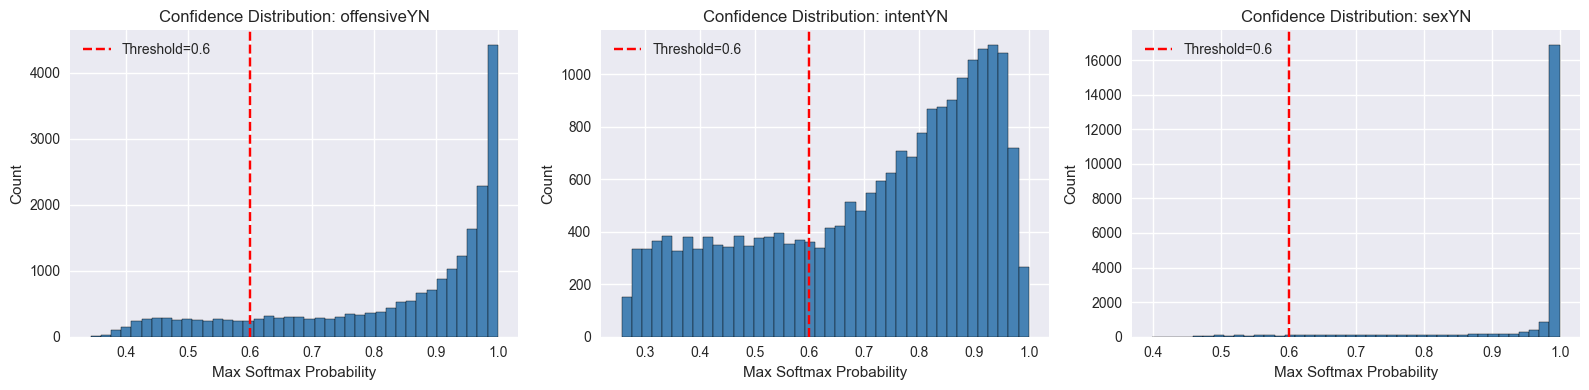

In [22]:
# if the model's max probability is below this, it's uncertain
CONFIDENCE_THRESHOLD = 0.6

max_conf_off = np.max(proba_off, axis=1)
max_conf_int = np.max(proba_int, axis=1)
max_conf_sex = np.max(proba_sex, axis=1)

# count how many predictions fall below the threshold
uncertain_off = (max_conf_off < CONFIDENCE_THRESHOLD).sum()
uncertain_int = (max_conf_int < CONFIDENCE_THRESHOLD).sum()
uncertain_sex = (max_conf_sex < CONFIDENCE_THRESHOLD).sum()

print(f"Uncertain predictions (confidence < {CONFIDENCE_THRESHOLD}):")
print(f"  offensiveYN: {uncertain_off} / {len(X_test)} ({100*uncertain_off/len(X_test):.1f}%)")
print(f"  intentYN:    {uncertain_int} / {len(X_test)} ({100*uncertain_int/len(X_test):.1f}%)")
print(f"  sexYN:       {uncertain_sex} / {len(X_test)} ({100*uncertain_sex/len(X_test):.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, conf, name in zip(axes,
                           [max_conf_off, max_conf_int, max_conf_sex],
                           ['offensiveYN', 'intentYN', 'sexYN']):
    ax.hist(conf, bins=40, color='steelblue', edgecolor='black')
    ax.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', label=f'Threshold={CONFIDENCE_THRESHOLD}')
    ax.set_title(f'Confidence Distribution: {name}')
    ax.set_xlabel('Max Softmax Probability')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

 Training History Plot

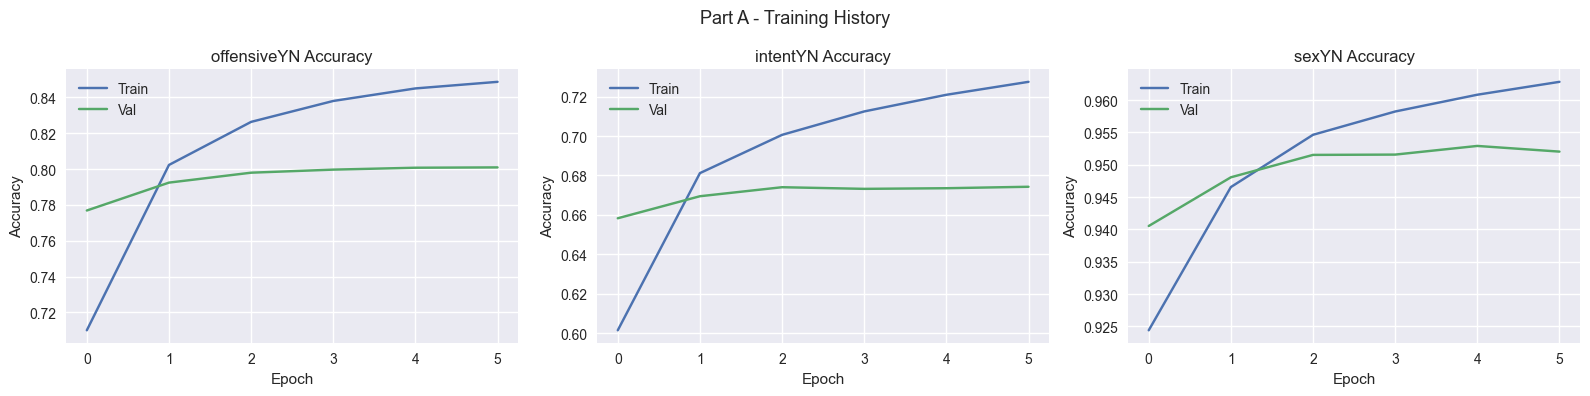

In [25]:
# plot how accuracy changed over training epochs
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, name in zip(axes,
    ['offensiveYN_accuracy', 'intentYN_accuracy', 'sexYN_accuracy'],
    ['offensiveYN', 'intentYN', 'sexYN']):
    ax.plot(history.history[metric], label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val')
    ax.set_title(f'{name} Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.suptitle('Part A - Training History', fontsize=13)
plt.tight_layout()
plt.show()

Save Model

In [24]:
# save the trained model
model.save('models/part_a_model.keras')
print("Model saved.")

Model saved.
